In [ ]:
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from Oscillators import Oscillator
import time
keras = tf.keras
#loeading testing values 
tf.random.set_seed(42)
np.random.seed(42)

def collect_data(sample_number,length,intervals,  osc_class):
    steps = np.linspace(0, length, intervals)
    val_data = np.zeros((sample_number, 1, intervals))
    init_var_data = np.zeros((sample_number, 6))

    for i in range(sample_number):
        init_conditions = np.random.rand(6)

        init_conditions[0] = 0.1 + 0.9 * init_conditions[0]  # mass: 0.1-1.0
        init_conditions[1] = 0.5 + 1.5 * init_conditions[1]  # k: 0.5-2.0
        init_conditions[2] = 0.1 + 0.9 * init_conditions[2]  # A0: 0.1-1.0
        init_conditions[3] = 0.1 * init_conditions[3]        # b: 0-0.1
        init_conditions[4] = 0.1 * init_conditions[4]        # F0: 0-0.1
        init_conditions[5] = 0.5 * init_conditions[5]  

        osc_obj = osc_class(*init_conditions)
        
        val_data[i] = np.array(osc_obj.get_x_pos(steps))
        init_var_data[i] = init_conditions

    return init_var_data, val_data


def preparing_data(init_var, series, batch_size = 32, shuffle_buffer = 1000, training_data = True):
    dataset = tf.data.Dataset.from_tensor_slices((init_var, series))
    if (training_data) : dataset = dataset.shuffle(shuffle_buffer)
    dataset = dataset.batch(batch_size).prefetch(1)
    return dataset


model = keras.models.Sequential([
    keras.layers.Input(shape = (6,)),
    keras.layers.RepeatVector(500),
    keras.layers.SimpleRNN(100, return_sequences=True),
    keras.layers.SimpleRNN(100, return_sequences= True),
    keras.layers.TimeDistributed(keras.layers.Dense(1))
    ])

initial_values, series_values = collect_data(1000, 50, 500, Oscillator)
train_set = preparing_data(initial_values, series_values, batch_size= 128)

lr_schedule = keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-7 * 10**(epoch / 20))

optimizer = keras.optimizers.SGD(learning_rate=1e-7, momentum=0.9)
model.compile(loss=keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])

# early_stopping = keras.callbacks.EarlyStopping(patience=50)
# model_checkpoint = keras.callbacks.ModelCheckpoint(
#     "my_checkpoint", save_best_only=True)

history = model.fit(train_set, epochs = 50, callbacks=[lr_schedule])

#model.fit(train_set, epochs=500, callbacks=[early_stopping, model_checkpoint])

#model = keras.models.load_model("my_checkpoint")



#export_path_keras = "./{}.h5".format(int(time.time()))
#print(export_path_keras)

#model.save(export_path_keras)


# init_v, s = collect_data(2, 10, 10, Oscillator)
# preparing_data(init_v, s)

Epoch 1/50
8/8 [==============================] - 12s 1s/step - loss: 0.0450 - mae: 0.2354 - lr: 1.0000e-07
Epoch 2/50
8/8 [==============================] - 10s 1s/step - loss: 0.0450 - mae: 0.2352 - lr: 1.1220e-07
Epoch 3/50
8/8 [==============================] - 10s 1s/step - loss: 0.0450 - mae: 0.2350 - lr: 1.2589e-07
Epoch 4/50
8/8 [==============================] - 10s 1s/step - loss: 0.0450 - mae: 0.2348 - lr: 1.4125e-07
Epoch 5/50


KeyboardInterrupt: 

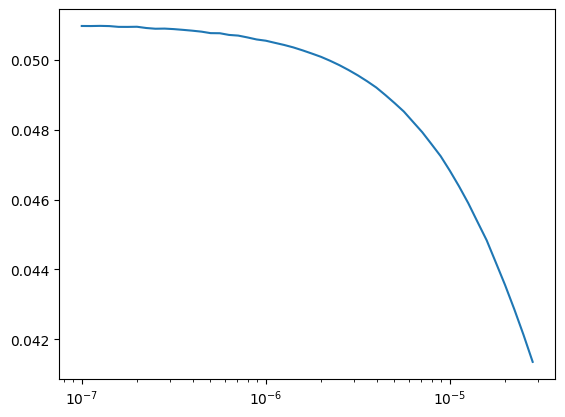

In [ ]:

plt.semilogx(history.history["lr"], history.history["loss"])
#plt.axis([1e-7, 1e-4, 0, 30])
plt.show()

Full RNN Model


In [16]:
model = keras.models.Sequential([
    keras.layers.Input(shape = (6,)),
    keras.layers.RepeatVector(500),
    keras.layers.SimpleRNN(100, return_sequences=True),
    keras.layers.SimpleRNN(100, return_sequences= True),
    keras.layers.TimeDistributed(keras.layers.Dense(1))
    ])

initial_values, series_values = collect_data(100, 50, 500, Oscillator)
train_set = preparing_data(initial_values, series_values, batch_size= 128)

validation_init_values, validation_series_values = collect_data(100, 50, 500, Oscillator)
validation_set = preparing_data(validation_init_values, validation_series_values, batch_size=128)


optimizer = keras.optimizers.SGD(learning_rate=1e-5, momentum=0.9)
model.compile(loss=keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])

early_stopping = keras.callbacks.EarlyStopping(patience=20)
model_checkpoint = keras.callbacks.ModelCheckpoint(
    "my_checkpoint", save_best_only=True)

#history = model.fit(train_set, epochs = 50, callbacks=[lr_schedule])

model.fit(train_set, epochs=500,
        callbacks=[early_stopping, model_checkpoint],
        validation_data = validation_set)

model = keras.models.load_model("my_checkpoint")

export_path_keras = "./{}.h5".format(int(time.time()))
print(export_path_keras)
model.save(export_path_keras)


Epoch 1/500
1/1 [==============================] - 5s 5s/step - loss: 0.0954 - mae: 0.3477 - val_loss: 0.0972 - val_mae: 0.3545
Epoch 2/500
1/1 [==============================] - 4s 4s/step - loss: 0.0953 - mae: 0.3475 - val_loss: 0.0970 - val_mae: 0.3540
Epoch 3/500
1/1 [==============================] - 4s 4s/step - loss: 0.0951 - mae: 0.3471 - val_loss: 0.0966 - val_mae: 0.3534
Epoch 4/500
1/1 [==============================] - 4s 4s/step - loss: 0.0948 - mae: 0.3467 - val_loss: 0.0962 - val_mae: 0.3526
Epoch 5/500
1/1 [==============================] - 4s 4s/step - loss: 0.0945 - mae: 0.3460 - val_loss: 0.0957 - val_mae: 0.3517
Epoch 6/500
1/1 [==============================] - 4s 4s/step - loss: 0.0941 - mae: 0.3453 - val_loss: 0.0951 - val_mae: 0.3506
Epoch 7/500
1/1 [==============================] - 4s 4s/step - loss: 0.0936 - mae: 0.3445 - val_loss: 0.0945 - val_mae: 0.3494
Epoch 8/500
1/1 [==============================] - 4s 4s/step - loss: 0.0931 - mae: 0.3436 - val_loss: 0

KeyboardInterrupt: 

1/1 [==============================] - 1s 529ms/step
[[[-0.742123  ]
  [ 0.00286791]
  [-0.35404748]
  [-0.13026066]
  [ 0.19704902]
  [ 0.10232766]
  [ 0.18374625]
  [ 0.28410235]
  [ 0.23176199]
  [ 0.26760438]
  [ 0.37393132]
  [ 0.39636457]
  [ 0.39333823]
  [ 0.39200208]
  [ 0.398488  ]
  [ 0.40140468]
  [ 0.40211886]
  [ 0.39702618]
  [ 0.40266144]
  [ 0.4024213 ]
  [ 0.40668997]
  [ 0.40752316]
  [ 0.40552396]
  [ 0.40557468]
  [ 0.40630573]
  [ 0.4054324 ]
  [ 0.40549865]
  [ 0.4056392 ]
  [ 0.40566632]
  [ 0.40562883]
  [ 0.40547937]
  [ 0.40537727]
  [ 0.40544066]
  [ 0.40533704]
  [ 0.4053092 ]
  [ 0.40532863]
  [ 0.40530276]
  [ 0.40529716]
  [ 0.40529954]
  [ 0.4052868 ]
  [ 0.4052946 ]
  [ 0.4052921 ]
  [ 0.40528542]
  [ 0.40529004]
  [ 0.40529093]
  [ 0.40528852]
  [ 0.40529   ]
  [ 0.40529   ]
  [ 0.40528995]
  [ 0.40529025]
  [ 0.40528986]
  [ 0.40529025]
  [ 0.40529066]
  [ 0.4052904 ]
  [ 0.4052903 ]
  [ 0.4052905 ]
  [ 0.40529028]
  [ 0.4052906 ]
  [ 0.40529084]
  [

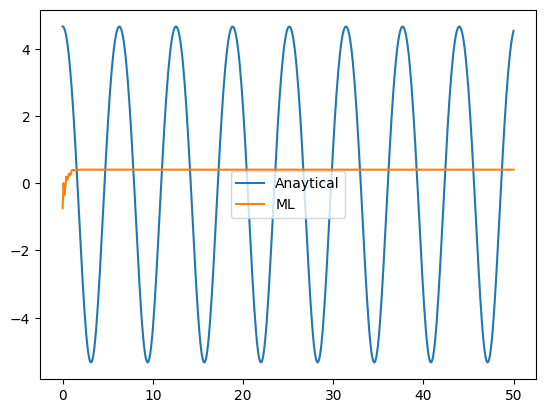

In [18]:
model = keras.models.load_model("my_checkpoint")


test_vals = [1,1,5,0,1,2]

oscillator = Oscillator(*test_vals)

t = np.linspace(0, 50, 500)
x = oscillator.get_x_pos(t)


forecast  = model.predict(np.array([test_vals]))
print(forecast)
plt.plot(t, x, label="Anaytical")
plt.plot(t, forecast[0], label = "ML")
plt.legend()
